# Project Pulse — Mapping Musical Taste by *Sound*, Not Behavior

**The motivation.** Streaming recommenders (Spotify's Discover Weekly / AI DJ) lean
heavily on *collaborative filtering* — they learn from collective listening behavior
(co-listens, skips, saves). That works well for mainstream taste, but it is known to
carry **popularity bias** and **cultural/country bias**: it under-serves listeners
whose taste spans languages and cultures, where co-listening data is thin and skewed
toward Western catalogs.

**The idea.** Build a map of music defined purely by **how a song sounds** — a 768-D
neural audio embedding (AST) — instead of how crowds behave. Then make it
**interpretable** (brightness, tempo, texture…) and **reusable** (anyone can drop their
songs onto the same frozen map and compare).

**Honest scope.** This is a personal case study (1 listener, 99 songs, Like/Dislike).
The AST model is itself Western-trained — we don't claim to have de-biased it. Our
honest edge is two things: the space is defined by *sound* not *behavior*, and its
reference anchors are a deliberately cross-cultural corpus.

---

### Notebook map
| Section | Purpose |
|---|---|
| 0. Setup | Imports + the `pulse_core` engine |
| 1. Load | Frozen reference space + features (starts from saved data) |
| 2. The Sound Space | Interactive 3D map (AST → UMAP, reusable) |
| 3. The Interpretable Space | *Why* a song sits where it does (named features) |
| 4. Does the machine agree? | Unsupervised clustering vs my real labels |
| 5. How separable is my taste? | One honest number |
| 6. Surface proxy vs deep sound | Why shallow descriptors aren't enough |
| 7. Place your songs | The reusable projector + your "taste type" |
| Appendix | The (disabled) raw-audio extraction pipeline |

> Heavy stages (downloading songs, extracting features) are **disabled**. This
> notebook starts from saved data and the frozen model artifacts in `artifacts/`.

## 0. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

import pulse_core
from pulse_core import (
    INTERPRETABLE_FEATURES, FEATURE_LABELS,
    load_reference_space, project_embeddings, assign_taste_type, place_audio_files,
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
PALETTE = {"Liked": "#00ffcc", "Disliked": "#ff3366"}
PALETTE_LIST = ["#00ffcc", "#ff3366"]
plt.style.use("dark_background")
sns.set_palette(sns.color_palette(PALETTE_LIST))
print("Setup complete — engine loaded from pulse_core.")

Setup complete — engine loaded from pulse_core.


## 1. Load — the analysis starts here

We load the **frozen reference space** (the fitted scaler + UMAP reducer + the
corpus coordinates) and the **interpretable features**, then join them. No audio is
processed here.

In [2]:
space = load_reference_space()            # scaler + UMAP reducer + reference coords
dim_cols = space["dim_cols"]              # the 768 AST dimensions
ref = space["reference_df"]               # Track, Preference, dim_*, X/Y/Z, UX/UY/UZ

interp = pd.read_csv(pulse_core.INTERPRETABLE_CSV)
df = ref.merge(interp, on=["Track", "Preference"], how="left")

# Standardised AST matrix (reused throughout)
X = space["scaler"].transform(df[dim_cols].values)

print(f"{len(df)} tracks | {len(dim_cols)} neural dims | "
      f"{len(INTERPRETABLE_FEATURES)} interpretable features")
print(df["Preference"].value_counts().to_string())
df[["Track", "Preference", "UX", "UY", "UZ"]].head()

99 tracks | 768 neural dims | 8 interpretable features
Preference
Disliked    50
Liked       49


,Track,Preference,UX,UY,UZ
0,Soneya (Official Music Video) - Asim Azhar,Liked,-2.809468,3.192962,7.563073
1,Mystery of Love,Liked,-2.312169,1.812002,4.850459
2,Nawab - Bhaga Bhaga Lyric (Telugu) ｜ @ARRahman...,Liked,-2.247796,3.606401,6.792701
3,Maanu - 4U (Official Music Video),Liked,-2.443203,4.361781,8.324639
4,Bu Kolthoum - Wallé ｜ بو كلثوم - ولّع,Liked,-3.106136,4.229653,8.109329


## 2. The Sound Space (AST → UMAP)

Each point is a song placed by its **acoustic fingerprint**. We use **UMAP** here
(not t-SNE) for one crucial reason: UMAP can place *new* songs into this exact, frozen
space later via `.transform()`. t-SNE cannot — it would have to recompute everything
and move all the points. That single property is what makes the map **reusable**.

In [3]:
def build_sound_map(df, save_to="Project_Pulse_Sound_Map.html"):
    """Interactive 3D map of the frozen sound space."""
    fig = px.scatter_3d(
        df, x="UX", y="UY", z="UZ", color="Preference",
        hover_name="Track", color_discrete_map=PALETTE,
        title="Project Pulse — The Sound Space (768-D AST embedding, UMAP)",
    )
    fig.update_traces(marker=dict(size=6, opacity=0.85))
    fig.update_layout(template="plotly_dark", margin=dict(l=0, r=0, b=0, t=40))
    if save_to:
        fig.write_html(save_to)
        print(f"Saved interactive map -> {save_to}")
    return fig

build_sound_map(df).show()

Saved interactive map -> Project_Pulse_Sound_Map.html


## 3. The Interpretable Space — *why* a song sits where it does

The AST map shows *that* songs differ; this section shows *how*, in plain English.
These eight features are physical and culture-neutral (brightness, tempo, texture,
dynamics, tonality), so they explain placement in words anyone understands.

In [4]:
# Taste profile: median of each feature, Liked vs Disliked
profile = df.groupby("Preference")[INTERPRETABLE_FEATURES].median().T
profile.index = [FEATURE_LABELS[f] for f in profile.index]
print("Your acoustic taste profile (median values):")
profile.round(3)

Your acoustic taste profile (median values):


Preference,Disliked,Liked
Brightness,2075.642,1635.425
Percussiveness,0.083,0.060
Tempo,123.047,117.454
Dynamic Range,0.010,0.007
Loud/Quiet Contrast,4.026,5.002
Abruptness,0.017,0.012
Tonal Stability,0.010,0.013
Melody vs Drums,3.668,5.522


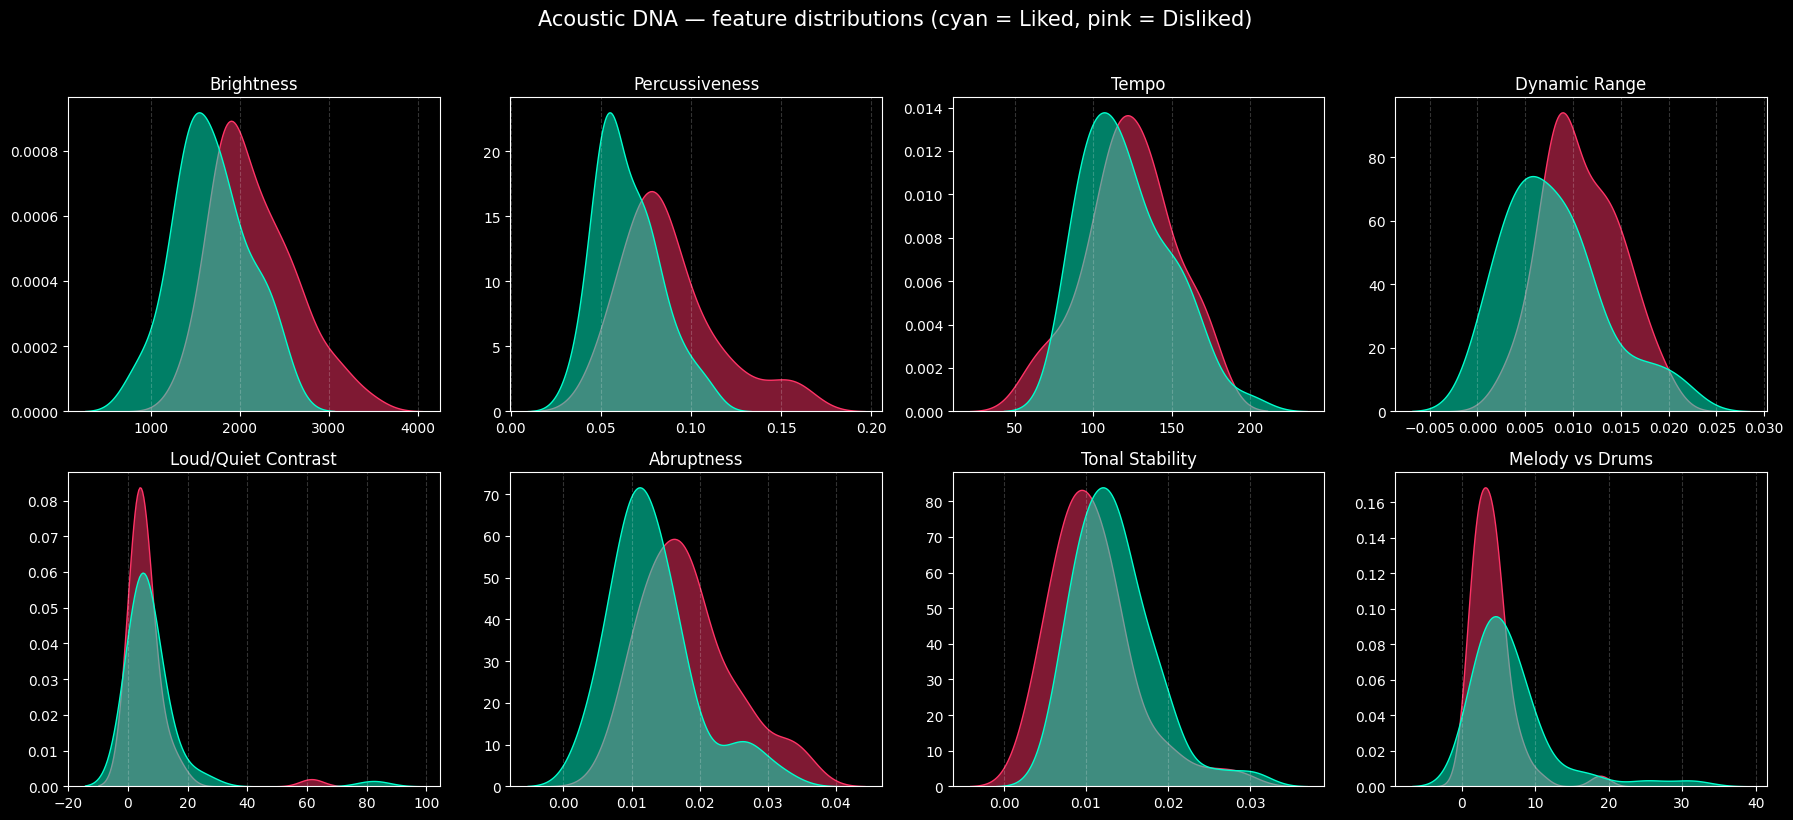

In [5]:
# Distribution of every interpretable feature, Liked vs Disliked
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Acoustic DNA — feature distributions (cyan = Liked, pink = Disliked)",
             fontsize=15, y=1.02)
for ax, feat in zip(axes.ravel(), INTERPRETABLE_FEATURES):
    sns.kdeplot(data=df, x=feat, hue="Preference", fill=True, alpha=0.5,
                palette=PALETTE, ax=ax, legend=False, common_norm=False)
    ax.set_title(FEATURE_LABELS[feat], fontsize=12)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.grid(axis="x", linestyle="--", alpha=0.2)
plt.tight_layout()
plt.show()

In [6]:
# A 3D interpretable map using the three most telling named axes (real units)
fig = px.scatter_3d(
    df, x="brightness_centroid", y="melody_to_drum_ratio", z="tempo_bpm",
    color="Preference", hover_name="Track", color_discrete_map=PALETTE,
    labels={"brightness_centroid": "Brightness (Hz)",
            "melody_to_drum_ratio": "Melody vs Drums",
            "tempo_bpm": "Tempo (BPM)"},
    title="The Interpretable Space — named acoustic axes",
)
fig.update_traces(marker=dict(size=6, opacity=0.85))
fig.update_layout(template="plotly_dark", margin=dict(l=0, r=0, b=0, t=40))
fig.show()

## 4. Does the machine agree with me?

If we hide my labels and let K-Means cluster the raw 768-D sound embeddings, do the
clusters line up with my actual Like/Dislike split? If yes, my taste has a real,
measurable acoustic basis.

In [7]:
df["blind_cluster"] = KMeans(n_clusters=2, random_state=RANDOM_STATE,
                             n_init=10).fit_predict(X)
purity = (df.groupby("blind_cluster")["Preference"]
            .value_counts().unstack(fill_value=0))
sil = silhouette_score(X, df["blind_cluster"])

print("Cluster composition (rows = machine cluster, cols = my labels):")
print(purity.to_string())
print(f"\nSilhouette score: {sil:.3f}")

# Honest, automatic reading of the result
dominant_share = (purity.max(axis=1) / purity.sum(axis=1)).mean()
print(f"\nReading: when the machine ignores my labels, the clusters it finds are "
      f"only ~{dominant_share:.0%} pure on average, and the silhouette is low. In "
      f"plain terms: my Likes and Dislikes OVERLAP heavily in sound space — there is "
      f"no clean acoustic wall between them. That overlap is itself a key finding.")

Cluster composition (rows = machine cluster, cols = my labels):
Preference     Disliked  Liked
blind_cluster                 
0                    43     38
1                     7     11

Silhouette score: 0.110

Reading: when the machine ignores my labels, the clusters it finds are only ~57% pure on average, and the silhouette is low. In plain terms: my Likes and Dislikes OVERLAP heavily in sound space — there is no clean acoustic wall between them. That overlap is itself a key finding.


## 5. How separable is my taste? (one honest number)

How well can a simple model predict Like vs Dislike from the **sound alone**? We report
5-fold cross-validated accuracy against the majority-class baseline. We are *not*
claiming this is all there is to taste — the gap below 100% is itself the point.

In [8]:
def separability(features_scaled, labels):
    """5-fold CV accuracy of predicting preference from features."""
    y = (labels == "Liked").astype(int)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(LogisticRegression(max_iter=2000),
                             features_scaled, y, cv=cv)
    return scores.mean(), scores.std()

acc, sd = separability(X, df["Preference"])
baseline = df["Preference"].value_counts(normalize=True).max()
print(f"Taste predictability from SOUND: {acc:.1%}  ± {sd:.1%}")
print(f"Majority-class baseline:         {baseline:.1%}")
print(f"\nReading: sound predicts my taste MEANINGFULLY better than a coin-flip "
      f"({acc:.0%} vs {baseline:.0%}), but it is far from perfect. Combined with the "
      f"heavy overlap from Section 4, the honest conclusion is: how a song SOUNDS is "
      f"part of why I like it — but a large part of my taste lives outside the audio "
      f"(lyrics, language familiarity, culture, context, memory).")

Taste predictability from SOUND: 67.8%  ± 9.0%
Majority-class baseline:         50.5%

Reading: sound predicts my taste MEANINGFULLY better than a coin-flip (68% vs 51%), but it is far from perfect. Combined with the heavy overlap from Section 4, the honest conclusion is: how a song SOUNDS is part of why I like it — but a large part of my taste lives outside the audio (lyrics, language familiarity, culture, context, memory).


## 6. Surface descriptors vs deep sound

Mainstream apps surface a handful of **shallow** descriptors (tempo, brightness,
energy). Here we compare how well *those* separate my taste versus the **deep**
768-D acoustic fingerprint.

> **Honesty note:** the "surface" space below is a **proxy** built from a few simple
> features — it is **NOT** Spotify's actual model (which is proprietary and combines
> collaborative filtering, NLP, and audio). It only contrasts shallow single-number
> descriptors with a deep acoustic representation.
>
> **What we actually find (and don't hide):** on *this* dataset the two score about
> the same — a few simple features separate my binary Like/Dislike roughly as well as
> the 768-D embedding. Two honest reasons: (1) with only ~99 songs and 768 dims, the
> deep classifier is in a small-data regime and its score is conservative; (2) my
> taste just isn't very separable by raw audio (Sections 4–5). So the deep embedding's
> real value here is **not** higher accuracy — it's the **structure** of the map:
> meaningful neighborhoods and the ability to *place any new song* in a shared space,
> which three numbers cannot give you.

Surface-descriptor proxy : 68.7%
Deep sound (768-D AST)   : 67.8%

Honest verdict: about the same. The deep space earns its keep through map STRUCTURE and the ability to place arbitrary songs — not raw separability.


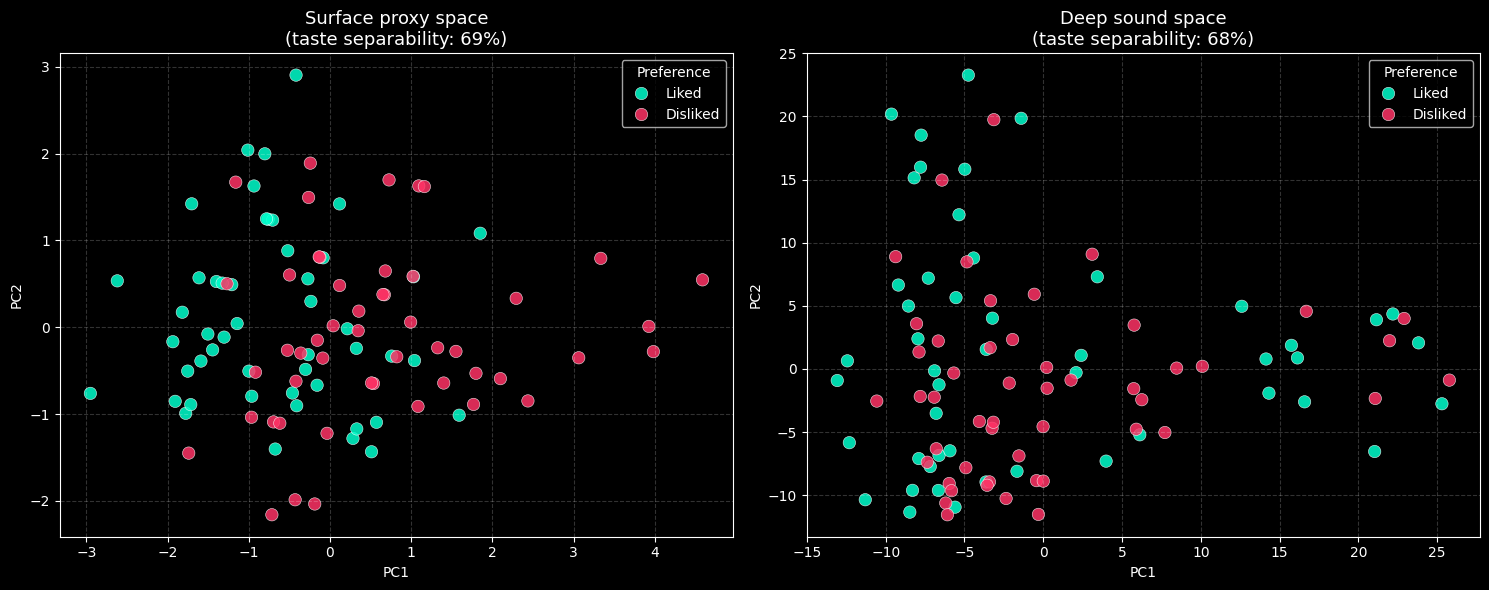

In [9]:
surface_feats = ["tempo_bpm", "brightness_centroid", "percussiveness_zcr"]
X_surface = StandardScaler().fit_transform(df[surface_feats])

acc_surface, _ = separability(X_surface, df["Preference"])
acc_deep, _ = separability(X, df["Preference"])

print(f"Surface-descriptor proxy : {acc_surface:.1%}")
print(f"Deep sound (768-D AST)   : {acc_deep:.1%}")
gap = acc_deep - acc_surface
verdict = ("about the same" if abs(gap) < 0.05
           else ("deep is higher" if gap > 0 else "surface is higher"))
print(f"\nHonest verdict: {verdict}. The deep space earns its keep through map "
      f"STRUCTURE and the ability to place arbitrary songs — not raw separability.")

# Side-by-side 2D PCA views
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (mat, title, acc) in zip(
    axes,
    [(X_surface, "Surface proxy space", acc_surface),
     (X,         "Deep sound space",    acc_deep)],
):
    xy = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(mat)
    tmp = pd.DataFrame({"PC1": xy[:, 0], "PC2": xy[:, 1],
                        "Preference": df["Preference"].values})
    sns.scatterplot(data=tmp, x="PC1", y="PC2", hue="Preference",
                    palette=PALETTE, s=80, alpha=0.85, edgecolor="white",
                    linewidth=0.4, ax=ax)
    ax.set_title(f"{title}\n(taste separability: {acc:.0%})", fontsize=13)
    ax.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Place your songs on the map (the reusable part)

`pulse_core.place_audio_files()` takes any audio file, extracts its AST embedding,
projects it into this frozen space, and returns its coordinates + a human-readable
**taste type**. This is the exact function a Colab notebook or a website backend would
call. The demo below runs it on two songs already in the corpus.

> Set `RUN_LIVE_DEMO = True` to run it (this loads the AST model the first time).

In [10]:
import os

# My overall taste type = the profile of everything I Liked
liked_centroid = df[df["Preference"] == "Liked"][INTERPRETABLE_FEATURES].median().to_dict()
print("My taste type:", assign_taste_type(liked_centroid, interp))

RUN_LIVE_DEMO = False
if RUN_LIVE_DEMO:
    sample = [
        Path("data/cluster_a_love") / sorted(os.listdir("data/cluster_a_love"))[0],
        Path("data/cluster_b_dislike") / sorted(os.listdir("data/cluster_b_dislike"))[0],
    ]
    placed = place_audio_files(sample, space=space, interpretable_ref=interp)
    display(placed[["Track", "UX", "UY", "UZ", "taste_type"]])
else:
    print("Live demo skipped. Set RUN_LIVE_DEMO = True to project real audio files.")

My taste type: Warm · Smooth · Steady · Melodic
Live demo skipped. Set RUN_LIVE_DEMO = True to project real audio files.


---
## Appendix — Raw-Audio Extraction Pipeline (DISABLED)

The original download + feature-extraction code lives in `pulse_core.py`
(`build_interpretable_dataset`, `extract_neural_embedding`, `fit_reference_space`).
It is **not** run here. To rebuild everything from raw audio you would set the flag
below and call those functions — but the saved CSVs + `artifacts/` already contain
the results, so there is no need.

In [11]:
ENABLE_AUDIO_EXTRACTION = False

if ENABLE_AUDIO_EXTRACTION:
    # WARNING: slow (~15-20 min) and needs the data/ audio folders + heavy deps.
    pulse_core.build_interpretable_dataset()          # named features -> CSV
    pulse_core.fit_reference_space()                  # refit + freeze UMAP artifacts
    print("Rebuilt features and reference space from raw audio.")
else:
    print("Audio extraction DISABLED — analysis runs from saved data + artifacts/.")

Audio extraction DISABLED — analysis runs from saved data + artifacts/.
